In [ ]:
from datasets import load_dataset

ds = load_dataset("bastienp/visible-watermark-pita")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train.zip:   0%|          | 0.00/573M [00:00<?, ?B/s]

data/test.zip:   0%|          | 0.00/142M [00:00<?, ?B/s]

data/val.zip:   0%|          | 0.00/178M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/12539 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/3089 [00:00<?, ? examples/s]

Generating val split:   0%|          | 0/3888 [00:00<?, ? examples/s]

In [ ]:
print(ds)

DatasetDict({
    train: Dataset({
        features: ['image', 'bbox', 'id', 'area', 'image_id', 'category_id'],
        num_rows: 12539
    })
    test: Dataset({
        features: ['image', 'bbox', 'id', 'area', 'image_id', 'category_id'],
        num_rows: 3089
    })
    val: Dataset({
        features: ['image', 'bbox', 'id', 'area', 'image_id', 'category_id'],
        num_rows: 3888
    })
})


In [ ]:
import os
from pathlib import Path
from tqdm.auto import tqdm
import yaml

# Create directory structure
base_path = Path('yolo_dataset')
for split in ['train', 'val', 'test']:
    (base_path / 'images' / split).mkdir(parents=True, exist_ok=True)
    (base_path / 'labels' / split).mkdir(parents=True, exist_ok=True)

def convert_to_yolo(size, box):
    dw = 1. / size[0]
    dh = 1. / size[1]
    # HF box is [xmin, ymin, width, height]
    x = box[0] + box[2] / 2.0
    y = box[1] + box[3] / 2.0
    w = box[2]
    h = box[3]
    return (x * dw, y * dh, w * dw, h * dh)

# Process each split
for split in ['train', 'val', 'test']:
    print(f"Processing {split} split...")
    dataset_split = ds[split]

    for idx, item in enumerate(tqdm(dataset_split)):
        img = item['image']
        image_id = item['image_id'] if 'image_id' in item else idx
        filename = f"{split}_{image_id}"

        # Save image
        img_path = base_path / 'images' / split / f"{filename}.jpg"
        if not img_path.exists():
            img.convert('RGB').save(img_path)

        # Save label
        label_path = base_path / 'labels' / split / f"{filename}.txt"
        if not label_path.exists():
            with open(label_path, 'w') as f:
                # Assuming single class (watermark) for this dataset, adjust if multiple
                class_id = 0
                yolo_box = convert_to_yolo(img.size, item['bbox'])
                f.write(f"{class_id} {' '.join([f'{x:.6f}' for x in yolo_box])}\n")

# Create data.yaml
data_config = {
    'path': str(base_path.absolute()),
    'train': 'images/train',
    'val': 'images/val',
    'test': 'images/test',
    'names': {0: 'watermark'}
}

with open('watermark_data.yaml', 'w') as f:
    yaml.dump(data_config, f)

print("Dataset preparation complete! Configuration saved to watermark_data.yaml")

Processing train split...


  0%|          | 0/12539 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
# Process test split
split = 'test'
print(f"Processing {split} split...")
dataset_split = ds[split]

for idx, item in enumerate(tqdm(dataset_split)):
    img = item['image']
    image_id = item['image_id'] if 'image_id' in item else idx
    filename = f"{split}_{image_id}"

    # Save image
    img_path = base_path / 'images' / split / f"{filename}.jpg"
    if not img_path.exists():
        img.convert('RGB').save(img_path)

    # Save label
    label_path = base_path / 'labels' / split / f"{filename}.txt"
    if not label_path.exists():
        with open(label_path, 'w') as f:
            class_id = 0
            yolo_box = convert_to_yolo(img.size, item['bbox'])
            f.write(f"{class_id} {' '.join([f'{x:.6f}' for x in yolo_box])}\n")

Processing test split...


  0%|          | 0/3089 [00:00<?, ?it/s]

In [ ]:
# Create data.yaml
data_config = {
    'path': str(base_path.absolute()),
    'train': 'images/train',
    'val': 'images/val',
    'test': 'images/test',
    'names': {0: 'watermark'}
}

with open('watermark_data.yaml', 'w') as f:
    yaml.dump(data_config, f)

print("Dataset preparation complete! Configuration saved to watermark_data.yaml")

Dataset preparation complete! Configuration saved to watermark_data.yaml


### Sample Image Visualization

Let's visualize a sample image from the processed dataset with its corresponding bounding box to ensure the annotations are correct.

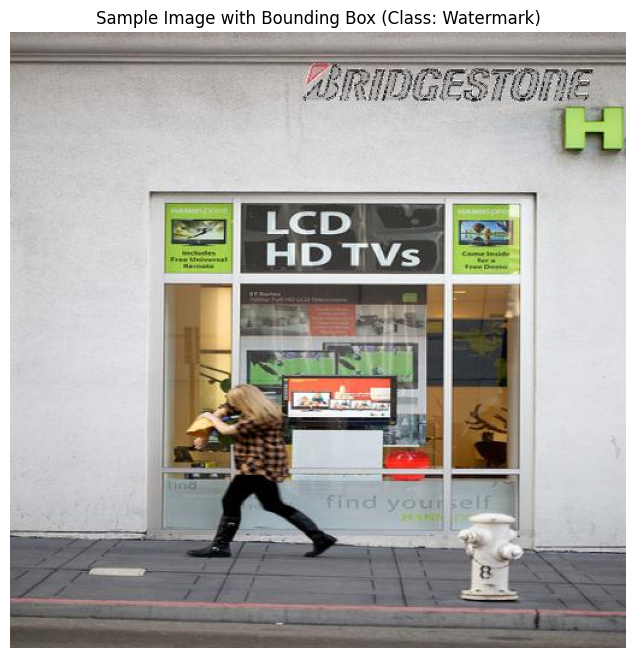

In [ ]:
import matplotlib.pyplot as plt
from PIL import ImageDraw

# Select a sample from the train split
sample_item = ds['train'][0]
image = sample_item['image']
bbox = sample_item['bbox']

# Create a drawing object
draw = ImageDraw.Draw(image.copy()) # Draw on a copy to avoid modifying the original PIL image

# Bounding box is [xmin, ymin, width, height]
xmin, ymin, width, height = bbox
xmax = xmin + width
ymax = ymin + height

# Draw the rectangle
draw.rectangle([xmin, ymin, xmax, ymax], outline="red", width=3)

# Display the image
plt.figure(figsize=(8, 8))
plt.imshow(image)
plt.title(f"Sample Image with Bounding Box (Class: Watermark)")
plt.axis('off')
plt.show()

### Training YOLOv8 Model with Custom Weights

First, we need to ensure `ultralytics` is installed. Then, we will load your `best.pt` weights and initiate training.

In [ ]:
# Install Ultralytics
!pip install ultralytics -qq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 26.3 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO

# Load your custom pre-trained YOLOv8 model weights from 'best.pt'
model = YOLO('best.pt')

# Train the model using the prepared dataset configuration
# Adjust 'epochs' and 'imgsz' as needed for your specific training goals
results = model.train(data='watermark_data.yaml', epochs=20, imgsz=640)

print("Training complete!")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=watermark_data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, 

After training, the results (e.g., trained weights, plots, and metrics) will be saved in a `runs` directory. You can inspect the `results` object for more details or visualize the training metrics directly.

In [ ]:
# Display the training results summary
print(results)

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7f71059dae40>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

### Inference on a Sample Image

Let's pick a sample image from the validation set and use our trained model to detect watermarks.

### Evaluate Model Performance on Validation Set

Let's run a full evaluation of the trained model on the validation dataset to get a complete set of performance metrics.

In [ ]:
from ultralytics import YOLO

# Load the trained model
model_path = '/content/runs/detect/train/weights/best.pt'
val_model = YOLO(model_path)

# Evaluate the model on the validation set
metrics = val_model.val(data='watermark_data.yaml')

# Print evaluation metrics
print("Model Evaluation Metrics:")
print(f"Precision (P): {metrics.box.p}")
print(f"Recall (R): {metrics.box.r}")
print(f"mAP50: {metrics.box.map50}")
print(f"mAP50-95: {metrics.box.map}")
print(f"F1 Score: {metrics.box.f1}")

Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1025.8±380.2 MB/s, size: 45.5 KB)
val: Scanning /content/yolo_dataset/labels/val.cache... 3888 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 3888/3888 815.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 243/243 6.1it/s 40.0s
                   all       3888       3888      0.716      0.814      0.829      0.352
Speed: 1.2ms preprocess, 3.7ms inference, 0.0ms loss, 1.2ms postprocess per image
Results saved to /content/runs/detect/val
Model Evaluation Metrics:
Precision (P): [    0.71621]
Recall (R): [    0.81353]
mAP50: 0.8285718332741154
mAP50-95: 0.35180155753125525
F1 Score: [    0.76177]
